# ARICast — Phase 0: Data Acquisition & Inspection

**Project:** forecasting acute respiratory illness (ARI) ED visit load, to support a shift
from reactive to proactive respiratory-surge staffing.

**Goal of this notebook:** load the raw CDC NSSP dataset, inspect its structure and integrity,
extract the two target series we model (national + California), reshape them into the schema
Prophet expects (`ds`, `y`), and persist clean inputs for the downstream notebooks.

**Data source:** CDC NSSP *Emergency Department Respiratory Daily* — dataset ID `vjzj-u7u8`,
data.cdc.gov, public domain.

---

### What this metric *is*

The dataset reports the **percent of all ED visits** attributed to a respiratory pathogen —
**not an absolute patient count**. We use the **ARI** (Acute Respiratory Illness) series as a
proxy for overall respiratory-driven ED load. In a production setting backed by an EHR, the same
approach would target an internal daily census instead. Naming this limitation up front is
deliberate: it is how the data must be interpreted, not a flaw to hide.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RAW_PATH = Path("../data/raw/NSSP_Emergency_Department_Respiratory_Daily.csv")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TARGET_PATHOGEN = "ARI"                          # broadest load signal
GEOGRAPHIES = ["United States", "California"]      # national + state-level model

## 2. Load raw data

In [2]:
df = pd.read_csv(RAW_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (281008, 4)
Columns: ['date', 'pathogen', 'geography', 'percent_visits']


,date,pathogen,geography,percent_visits
0,09/25/2022 12:00:00 AM,ARI,Alabama,15.99
1,09/26/2022 12:00:00 AM,ARI,Alabama,14.34
2,09/27/2022 12:00:00 AM,ARI,Alabama,15.17
3,09/28/2022 12:00:00 AM,ARI,Alabama,13.78
4,09/29/2022 12:00:00 AM,ARI,Alabama,13.70


In [3]:
# Source timestamp format example: '09/25/2022 12:00:00 AM'
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y %I:%M:%S %p")
df = df.sort_values("date").reset_index(drop=True)
df.dtypes

date              datetime64[us]
pathogen                     str
geography                    str
percent_visits           float64
dtype: object

## 3. Inspect structure

Verify what the file contains before modeling: which pathogens and geographies are present,
the time span, and the distribution of the target.

In [4]:
print("Pathogens:", sorted(df['pathogen'].unique()))
print("Geographies:", df['geography'].nunique(), "distinct")
print("Date span:", df['date'].min().date(), "->", df['date'].max().date())
print("\npercent_visits summary (all rows):")
df['percent_visits'].describe()

Pathogens: ['ARI', 'COVID', 'Influenza', 'RSV']
Geographies: 52 distinct
Date span: 2022-09-25 -> 2026-06-06

percent_visits summary (all rows):


count    281008.000000
mean          4.000103
std           5.948840
min           0.000000
25%           0.160000
50%           0.800000
75%           6.670000
max          38.860000
Name: percent_visits, dtype: float64

In [5]:
# Why ARI and not COVID / Influenza / RSV: ARI is the broadest, highest-amplitude
# load signal; the others are narrow sub-components. Quick comparison of mean level:
df.groupby('pathogen')['percent_visits'].agg(['mean', 'min', 'max']).round(2)

,mean,min,max
pathogen,,,
ARI,13.12,0.0,38.86
COVID,1.15,0.0,7.35
Influenza,1.43,0.0,21.81
RSV,0.30,0.0,4.95


## 4. Extract and reshape the two target series

Filter to `pathogen == 'ARI'` for each geography, keep `(date, percent_visits)`, and rename to
Prophet's schema `(ds, y)`.

In [6]:
def to_prophet_frame(frame, geography, pathogen=TARGET_PATHOGEN):
    s = frame[(frame["geography"] == geography) & (frame["pathogen"] == pathogen)].copy()
    s = s.sort_values("date")[["date", "percent_visits"]]
    return s.rename(columns={"date": "ds", "percent_visits": "y"}).reset_index(drop=True)

series = {geo: to_prophet_frame(df, geo) for geo in GEOGRAPHIES}
for geo, s in series.items():
    print(f"{geo:14s} {len(s)} rows  {s['ds'].min().date()} -> {s['ds'].max().date()}")
series["United States"].head()

United States  1351 rows  2022-09-25 -> 2026-06-06
California     1351 rows  2022-09-25 -> 2026-06-06


,ds,y
0,2022-09-25,14.14
1,2022-09-26,13.21
2,2022-09-27,13.13
3,2022-09-28,13.10
4,2022-09-29,13.00


## 5. Integrity check

For a daily time series the non-negotiables are: no missing calendar days, no duplicate dates,
and an explicit count of zero values (a state-level small-count suppression artifact in NSSP).

In [7]:
def integrity_report(s, geography, pathogen=TARGET_PATHOGEN):
    expected = pd.date_range(s["ds"].min(), s["ds"].max(), freq="D")
    return {
        "geography": geography,
        "rows": len(s),
        "expected_days": len(expected),
        "missing_days": len(expected) - s["ds"].nunique(),
        "duplicate_dates": int(s["ds"].duplicated().sum()),
        "zero_values": int((s["y"] == 0).sum()),
    }

report = pd.DataFrame([integrity_report(series[g], g) for g in GEOGRAPHIES])
print(report.to_string(index=False))
assert (report["missing_days"] == 0).all(), "missing calendar days!"
assert (report["duplicate_dates"] == 0).all(), "duplicate dates!"
print("\nIntegrity OK: both series are gap-free, duplicate-free daily series.")

    geography  rows  expected_days  missing_days  duplicate_dates  zero_values
United States  1351           1351             0                0            0
   California  1351           1351             0                0            0

Integrity OK: both series are gap-free, duplicate-free daily series.


## 6. Visual sanity check

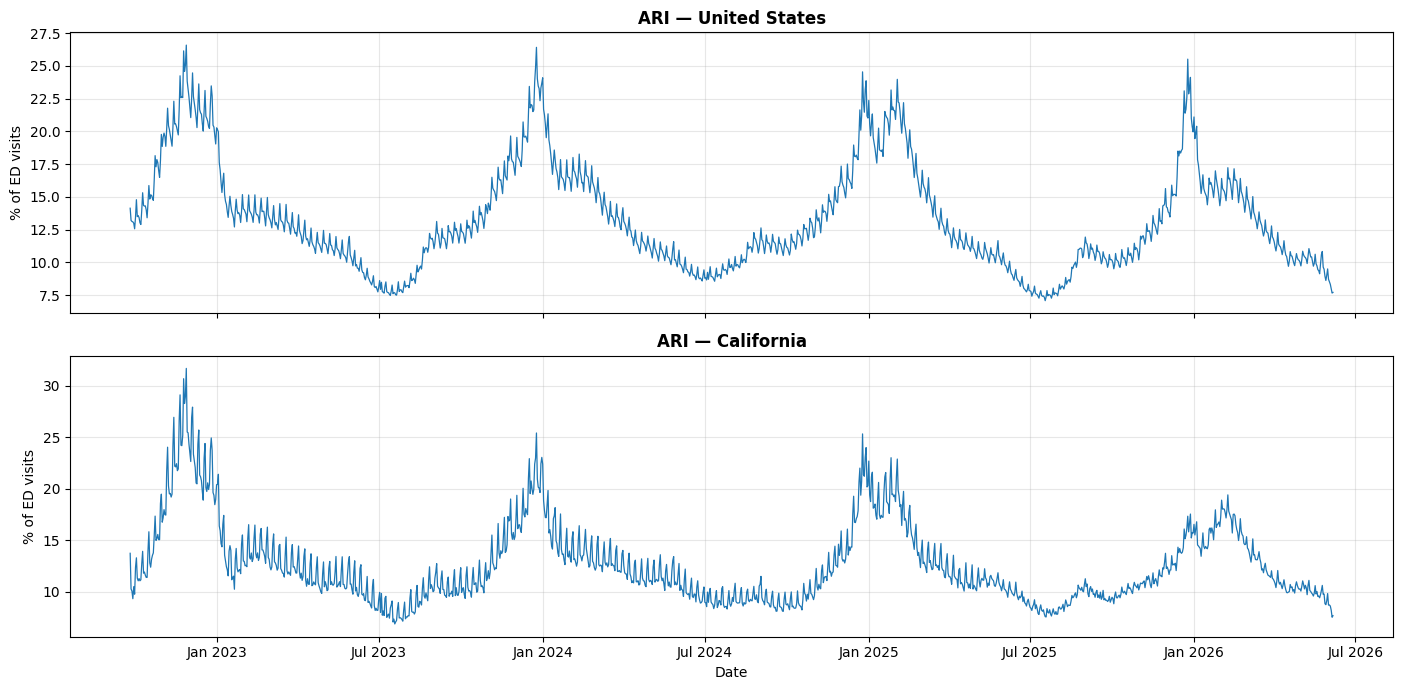

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, geo in zip(axes, GEOGRAPHIES):
    s = series[geo]
    ax.plot(s["ds"], s["y"], lw=0.9)
    ax.set_title(f"ARI — {geo}", fontweight="bold")
    ax.set_ylabel("% of ED visits")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

The two series share the same strong yearly shape (winter peak, summer trough) but differ
in amplitude — California's peaks run higher. This is the reason ARICast models the two
geographies **separately** rather than with a single region regressor.

## 7. Persist clean inputs

In [9]:
for geo in GEOGRAPHIES:
    fname = "ari_" + geo.lower().replace(" ", "_") + ".csv"
    series[geo].to_csv(PROCESSED_DIR / fname, index=False)
    print("wrote", PROCESSED_DIR / fname)

wrote ../data/processed/ari_united_states.csv
wrote ../data/processed/ari_california.csv
